<a href="https://colab.research.google.com/github/amirmohammadkalateh/LeNet/blob/main/LeNet_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.8359 - loss: 0.5394 - val_accuracy: 0.9754 - val_loss: 0.0822
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9761 - loss: 0.0806 - val_accuracy: 0.9828 - val_loss: 0.0573
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.9828 - loss: 0.0544 - val_accuracy: 0.9862 - val_loss: 0.0494
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.9874 - loss: 0.0391 - val_accuracy: 0.9862 - val_loss: 0.0452
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9903 - loss: 0.0321 - val_accuracy: 0.9871 - val_loss: 0.0476
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step - accuracy: 0.9929 - loss: 0.0225 - val_accuracy: 0.9888 - val_loss: 0.0408
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9927 - loss: 0.0215 - val_accuracy: 0.9871 - val_loss: 0.0479
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9943 - loss: 0.0170 - 

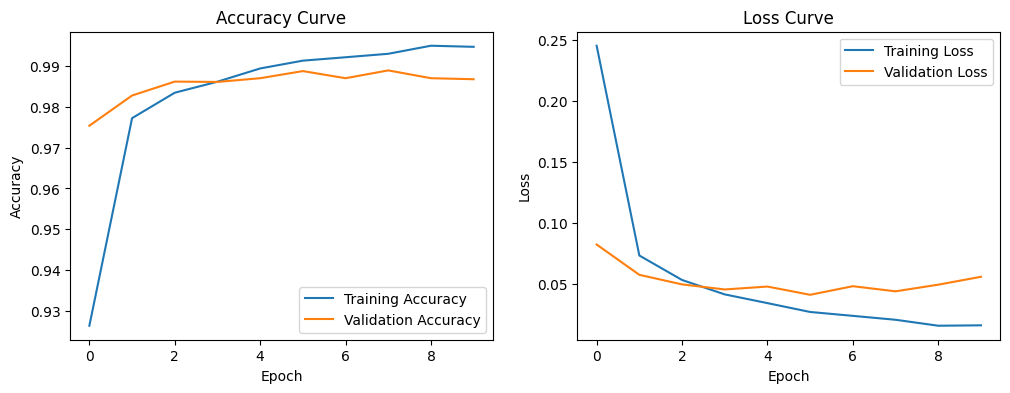

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


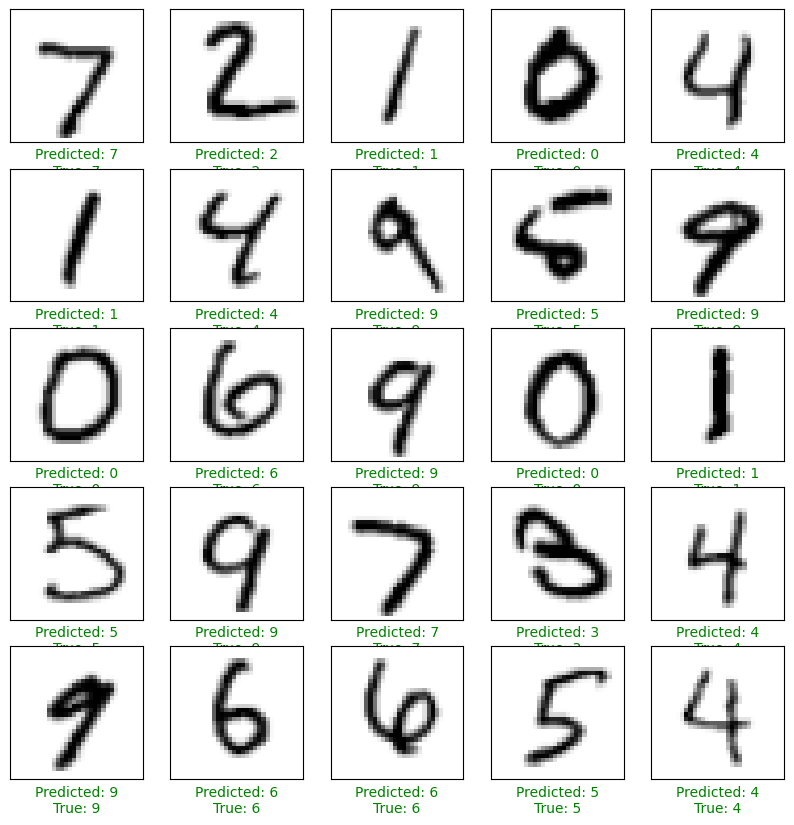

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

# Define the LeNet-5 model
def create_lenet5_model(input_shape=(32, 32, 1), num_classes=10):

    model = models.Sequential([
        # Convolutional Layer 1
        layers.Conv2D(6, (5, 5), activation='relu', input_shape=input_shape, name='conv1'),
        # Pooling Layer 1
        layers.MaxPooling2D((2, 2), name='pool1'),
        # Convolutional Layer 2
        layers.Conv2D(16, (5, 5), activation='relu', name='conv2'),
        # Pooling Layer 2
        layers.MaxPooling2D((2, 2), name='pool2'),
        # Flatten the output for the fully connected layers
        layers.Flatten(name='flatten'),
        # Fully Connected Layer 1
        layers.Dense(120, activation='relu', name='fc1'),
        # Fully Connected Layer 2
        layers.Dense(84, activation='relu', name='fc2'),
        # Output Layer
        layers.Dense(num_classes, activation='softmax', name='output'),
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Load and preprocess the MNIST dataset
def load_and_preprocess_mnist():

    (train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

    # Expand dimensions to (num_samples, 28, 28, 1)
    train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
    test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)

    # Resize images to 32x32
    train_images_resized = tf.image.resize(train_images, [32, 32])
    test_images_resized = tf.image.resize(test_images, [32, 32])

    # Normalize pixel values to be between 0 and 1
    train_images_normalized = train_images_resized / 255.0
    test_images_normalized = test_images_resized / 255.0

    # Convert labels to one-hot encoding
    train_labels_one_hot = tf.keras.utils.to_categorical(train_labels, num_classes=10)
    test_labels_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=10)

    return train_images_normalized, train_labels_one_hot, test_images_normalized, test_labels_one_hot

def visualize_training(history):

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Curve')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')
    plt.show()

def visualize_predictions(model, test_images, test_labels, class_names=None):

    predictions = model.predict(test_images)
    predicted_labels = tf.argmax(predictions, axis=1).numpy()
    true_labels = tf.argmax(test_labels, axis=1).numpy()

    if class_names is None:
        class_names = [str(i) for i in range(10)]  # Default to digits 0-9

    plt.figure(figsize=(10, 10))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(test_images[i], cmap=plt.cm.binary)
        predicted_label = class_names[predicted_labels[i]]
        true_label = class_names[true_labels[i]]
        if predicted_label == true_label:
            color = 'green'
        else:
            color = 'red'
        plt.xlabel(f"Predicted: {predicted_label}\nTrue: {true_label}", color=color)
    plt.show()

def main():

    # Load and preprocess the MNIST dataset
    train_images, train_labels, test_images, test_labels = load_and_preprocess_mnist()

    # Create the LeNet-5 model
    model = create_lenet5_model(input_shape=(32, 32, 1), num_classes=10)
    model.summary() #prints the model summary

    # Train the model
    history = model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_split=0.2)

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(test_images, test_labels)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    # Visualize training history
    visualize_training(history)

    # Visualize predictions
    visualize_predictions(model, test_images[:25], test_labels[:25])

if __name__ == "__main__":
    main()
